<a href="https://colab.research.google.com/github/ravshanbek-ds/Arduino/blob/main/05-ml-07-LinerRegression-amaliyot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Imgur](https://i.imgur.com/5pXzCIu.png)

# Data Science va Sun'iy Intellekt Praktikum

## 5-MODUL. Machine Learning.

### Linear Regression

In [1]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_LR.csv', index_col=0)
df.head(10)

,district,rooms,size,level,max_levels,price
0,Юнусабадский,3,57.0,4,4,52000.0
1,Яккасарайский,2,52.0,4,5,56000.0
2,Чиланзарский,2,42.0,4,4,37000.0
3,Чиланзарский,3,65.0,1,4,49500.0
4,Чиланзарский,3,70.0,3,5,55000.0
5,Чиланзарский,1,28.0,1,4,25500.0
6,Чиланзарский,1,30.0,2,4,21200.0
7,Яккасарайский,2,32.0,5,5,20000.0
8,Учтепинский,2,51.0,3,4,26200.0
9,Чиланзарский,1,30.0,1,4,22200.0


# Ustunlar ta'rifi
- `location` - sotilayotgan uy manzili
- `district` - uy joylashgan tuman
- `rooms` - xonalar soni
- `size` - uy maydoni (kv.m)
- `level` - uy

In [2]:
df['district'].value_counts()

,count
district,
Чиланзарский,1616
Мирзо-Улугбекский,1342
Учтепинский,872
Юнусабадский,847
Мирабадский,717
Яккасарайский,628
Яшнободский,456
Шайхантахурский,356
Олмазорский,262


**Darsimiz uchun Chilonzor tumanidagi uylarning narxini bashorat qilib ko'ramiz**

In [3]:
housing = df[df.district=='Чиланзарский']
housing.head()

,district,rooms,size,level,max_levels,price
2,Чиланзарский,2,42.0,4,4,37000.0
3,Чиланзарский,3,65.0,1,4,49500.0
4,Чиланзарский,3,70.0,3,5,55000.0
5,Чиланзарский,1,28.0,1,4,25500.0
6,Чиланзарский,1,30.0,2,4,21200.0


In [10]:
X = housing['size'].to_numpy()
X

array([42., 65., 70., ..., 32., 70., 30.])

In [11]:
y = housing['price'].to_numpy()
y

array([37000., 49500., 55000., ..., 28000., 49800., 22914.])

**Narx va uy maydoni o'rtasida chiziqli bog'liqlik bor ekanini tekshirib ko'ramiz.**

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

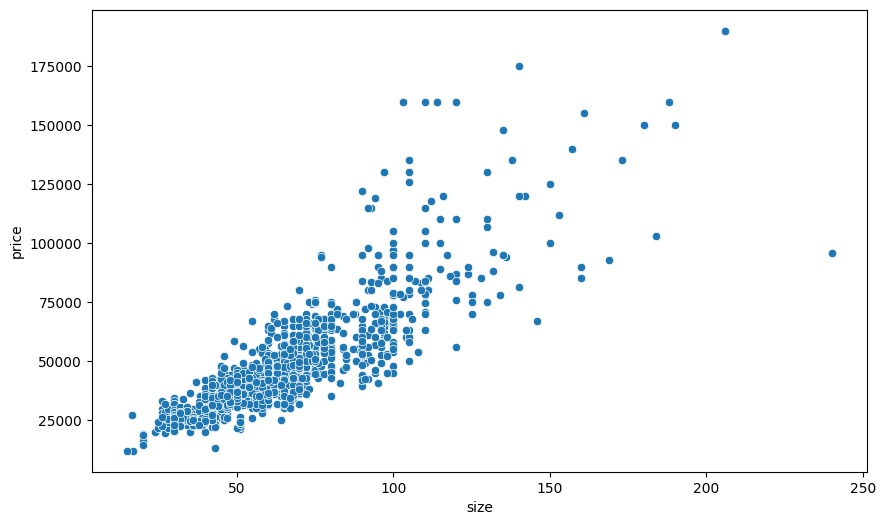

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=housing, x='size', y='price')
plt.show()

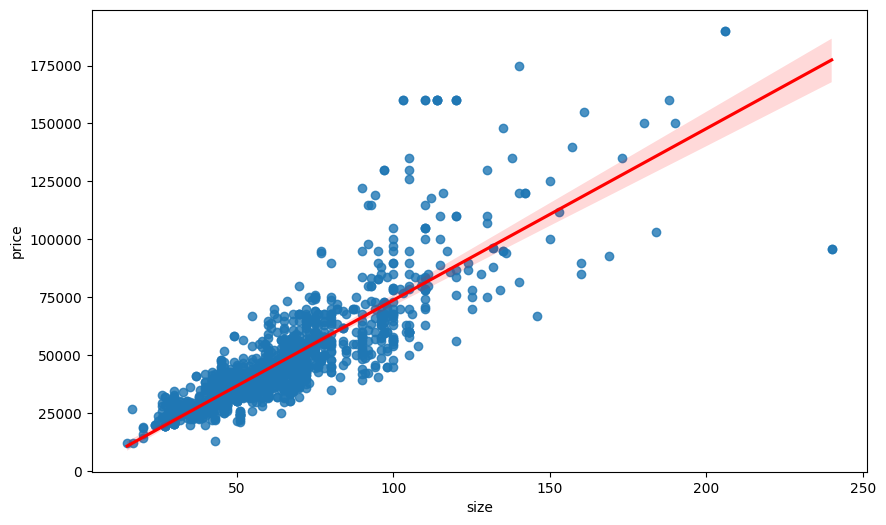

In [6]:
plt.figure(figsize=(10,6))
sns.regplot(data=housing, x='size', y='price', line_kws={"color": "red"})
plt.show()

## 1-Vazifa
Sizning vazifangiz yuqoridagi `X` va `y` o'zgaruvchilardan quyidagi formuladan foydalangan xolda $\theta_0$ va $\theta_1$ koeffisientlarni hisoblash.

![Imgur](https://i.imgur.com/zZoXZxI.png)

Bu yerda $\tilde{x}$ - `X` ustun uchun o'rtracha qiymat,  $\tilde{y}$ - `y` ustun uchun o'rtracha qiymat

In [18]:
import numpy as np

Xmean = np.mean(X)
ymean = np.mean(y)

In [19]:
theta1 = sum((X-Xmean)*(y-ymean))/sum((X-Xmean)**2)
print(f"{theta1=}")

theta1=np.float64(740.0264822713287)


In [20]:
theta0 = ymean - theta1*Xmean
print(f"{theta0=}")

theta0=np.float64(-195.94911352690542)


## 2-Vazifa
`X` dan bir nechta tasodifiy qiymatlarni ajratib oling va ularga mos keluvchi `y` ni yuqoridagi koeffisientlar yordamida hisoblab ko'ring.

![Imgur](https://i.imgur.com/iT5tffj.png)

In [21]:
x_test = housing.sample(10, random_state=42)['size'].to_numpy()
print(f"{x_test=}")
y_test = housing.sample(10, random_state=42)['price'].to_numpy()
print(f"{y_test=}")

x_test=array([54., 42., 36., 60., 48., 68., 38., 65., 52., 44.])
y_test=array([37500., 26500., 25500., 39000., 32500., 34500., 22700., 47000.,
       37900., 36000.])


In [22]:
y_predict = theta0 + theta1*x_test
print(f"{y_predict=}")

y_predict=array([39765.48092912, 30885.16314187, 26445.00424824, 44205.63982275,
       35325.3220355 , 50125.85168092, 27925.05721278, 47905.77223411,
       38285.42796458, 32365.21610641])


## 3-Vazifa

Hisoblangan va asl qiymtlar o'rtasidagi RMSE (root mean square error), MAE (mean absolute error) hisoblang.

![Imgur](https://i.imgur.com/GJH9CGy.png)

![Imgur](https://i.imgur.com/aXL9iWa.png)

In [23]:
# MAE
MAE = np.sum(np.absolute(y_predict-y_test))/len(y_test)
print(f"{MAE=}")

MAE=np.float64(4140.35031634715)


In [24]:
# RMSE
RMSE = np.sqrt(np.sum((y_predict-y_test)**2)/len(y_test))
print(f"{RMSE=}")

RMSE=np.float64(5882.051673173715)


### Real Case: Scikit-learn yordamida bashorat qilish

Real loyihalarda formulalarni qo'lda yozib o'tirmaymiz, balki tayyor kutubxonalardan foydalanamiz. Keling, `housing` ma'lumotlaridan bir nechta ustunni olib model quramiz.

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# 1. Kerakli ustunlarni tanlaymiz (X - faktorlar, y - natija)
features = ['size', 'rooms', 'level', 'max_levels']
X_multi = housing[features]
y_multi = housing['price']

# 2. Ma'lumotlarni o'qitish (train) va tekshirish (test) qismlariga bo'lamiz
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# 3. Modelni yaratamiz va o'qitamiz
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Bashorat qilamiz
y_pred = model.predict(X_test)

# 5. Xatolikni tekshiramiz
mae = mean_absolute_error(y_test, y_pred)
print(f"O'rtacha xatolik: {mae:.2f} $")

# Yangi uy uchun bashorat (Masalan: size=60, rooms=3, level=4, max_levels=5)
new_house = [[60, 3, 4, 5]]
predicted_price = model.predict(new_house)
print(f"Yangi uyning taxminiy narxi: {predicted_price[0]:.2f} $")

O'rtacha xatolik: 7681.09 $
Yangi uyning taxminiy narxi: 40593.96 $


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Ma'lumotlarni tayyorlash
# Narxi juda baland yoki maydoni juda kichik g'ayritabiiy ma'lumotlarni filtrlaymiz (ixtiyoriy lekin tavsiya etiladi)
df_clean = df[(df['price'] > 5000) & (df['price'] < 500000)]

X = df_clean.drop('price', axis=1)
y = df_clean['price']

# 2. Kategorik ustunlarni (tumanlarni) raqamga o'tkazish uchun Pipeline yaratamiz
categorical_features = ['district']
numeric_features = ['rooms', 'size', 'level', 'max_levels']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 3. Modelni yaratamiz (Random Forest ko'pincha aniqroq ishlaydi)
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

# 4. Modelni o'qitamiz
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model.fit(X_train_full, y_train_full)

# 5. Bashorat va MAE
y_pred_full = rf_model.predict(X_test_full)
new_mae = mean_absolute_error(y_test_full, y_pred_full)

print(f"Yangi modeldagi o'rtacha xatolik (MAE): {new_mae:.2f} $")
if new_mae < 1000:
    print("Tabriklayman! Xatolik 1000$ dan kamaydi.")
else:
    print("Xatolik hali ham yuqori. Ma'lumotlarni ko'proq tozalash yoki boshqa parametrlar kerak.")

Yangi modeldagi o'rtacha xatolik (MAE): 8108.03 $
Xatolik hali ham yuqori. Ma'lumotlarni ko'proq tozalash yoki boshqa parametrlar kerak.


### Natijalarni tahlil qilish

Bu model endi nafaqat uyning maydonini, balki qaysi qavatda joylashgani va xonalar sonini ham hisobga oladi. Real biznesda, masalan, banklar kredit berishda uyning qiymatini mana shunday modellar yordamida avtomatik hisoblashlari mumkin.